# Подготовка данных

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from db.core import db_to_csv
db_to_csv()

2026-04-06 17:45:51.134 | INFO     | db.core:db_to_csv:72 - Таблица sliver_predict_cost экспортирована в CSV.
2026-04-06 17:45:51.231 | INFO     | db.core:db_to_csv:72 - Таблица copper_predict_cost экспортирована в CSV.
2026-04-06 17:45:51.357 | INFO     | db.core:db_to_csv:72 - Таблица gold_cost экспортирована в CSV.
2026-04-06 17:45:51.494 | INFO     | db.core:db_to_csv:72 - Таблица sliver_cost экспортирована в CSV.
2026-04-06 17:45:51.609 | INFO     | db.core:db_to_csv:72 - Таблица copper_cost экспортирована в CSV.
2026-04-06 17:45:51.676 | INFO     | db.core:db_to_csv:72 - Таблица gold_predict_cost экспортирована в CSV.
2026-04-06 17:45:52.012 | INFO     | db.core:db_to_csv:72 - Таблица gold_news экспортирована в CSV.
2026-04-06 17:45:52.097 | INFO     | db.core:db_to_csv:72 - Таблица sliver_news экспортирована в CSV.
2026-04-06 17:45:52.186 | INFO     | db.core:db_to_csv:72 - Таблица copper_news экспортирована в CSV.


In [3]:
df_gold_cost = pd.read_csv('data/gold_cost.csv', index_col='date')

In [4]:
df_gold_cost.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1750 entries, 2019-04-08 to 2026-04-03
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    1750 non-null   float64
 1   high    1750 non-null   float64
 2   low     1750 non-null   float64
 3   close   1750 non-null   float64
dtypes: float64(4)
memory usage: 68.4+ KB


In [5]:
# def tonality(df_news, df_cost) -> pd.DataFrame:
#     tonality_dict = {}
#     for idx, row in df_cost.iterrows():
#         tonality_dict[row['date']] = 1 if row['open'] < row['close'] else -1
#     df_news['tonality'] = df_news['date'].map(tonality_dict)
#
#     return df_news
#
# tonality(df_gold_news,df_gold_cost)

# Работа с временными рядами

In [6]:
df_gold_cost_close = df_gold_cost[['close']]

In [7]:
df_gold_cost_close.head()

,close
date,
2019-04-08,2718.5
2019-04-09,2710.0
2019-04-10,2707.5
2019-04-11,2689.0
2019-04-12,2677.5


<Axes: xlabel='date'>

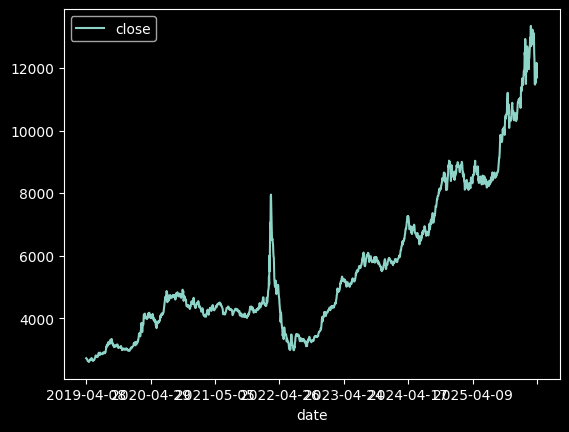

In [8]:
df_gold_cost_close.plot()

## Moving Average

In [9]:
def moving_average(df, window_size):
    return df.rolling(window=window_size, min_periods=1).mean()

In [10]:
df_gcc_ma = moving_average(df_gold_cost_close, window_size=30)
df_gcc_ma.head()

,close
date,
2019-04-08,2718.50
2019-04-09,2714.25
2019-04-10,2712.00
2019-04-11,2706.25
2019-04-12,2700.50


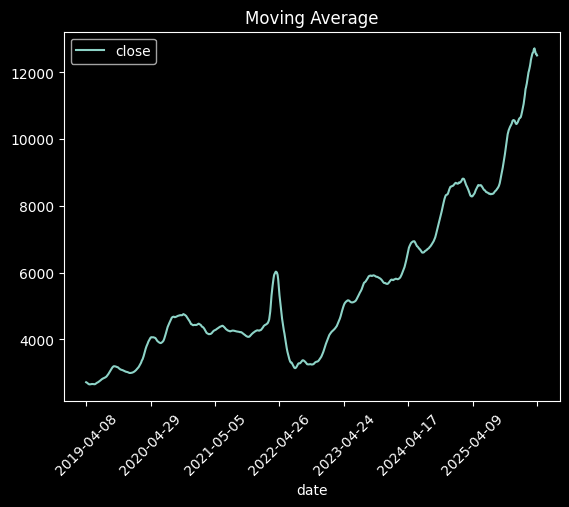

In [11]:
df_gcc_ma.plot()
plt.xticks(rotation=45)
plt.title('Moving Average')
plt.show()

In [12]:
# Рассчет среднеквадратичного отклонения
simg = np.sqrt(np.mean((df_gold_cost_close['close'] - df_gcc_ma['close']) ** 2))
print(f"Среднеквадратичное отклонение: {simg}")

Среднеквадратичное отклонение: 334.0779068060711


In [13]:
df_gcc_ma['close_plus_1.5_sigm'] = df_gcc_ma['close'] + 1.5 * simg
df_gcc_ma['close_minus_1.5_sigm'] = df_gcc_ma['close'] - 1.5 * simg
df_gcc_ma['real_close'] = df_gold_cost_close['close']
df_gcc_ma.rename({'close': 'moving_average'}, axis=1, inplace=True)

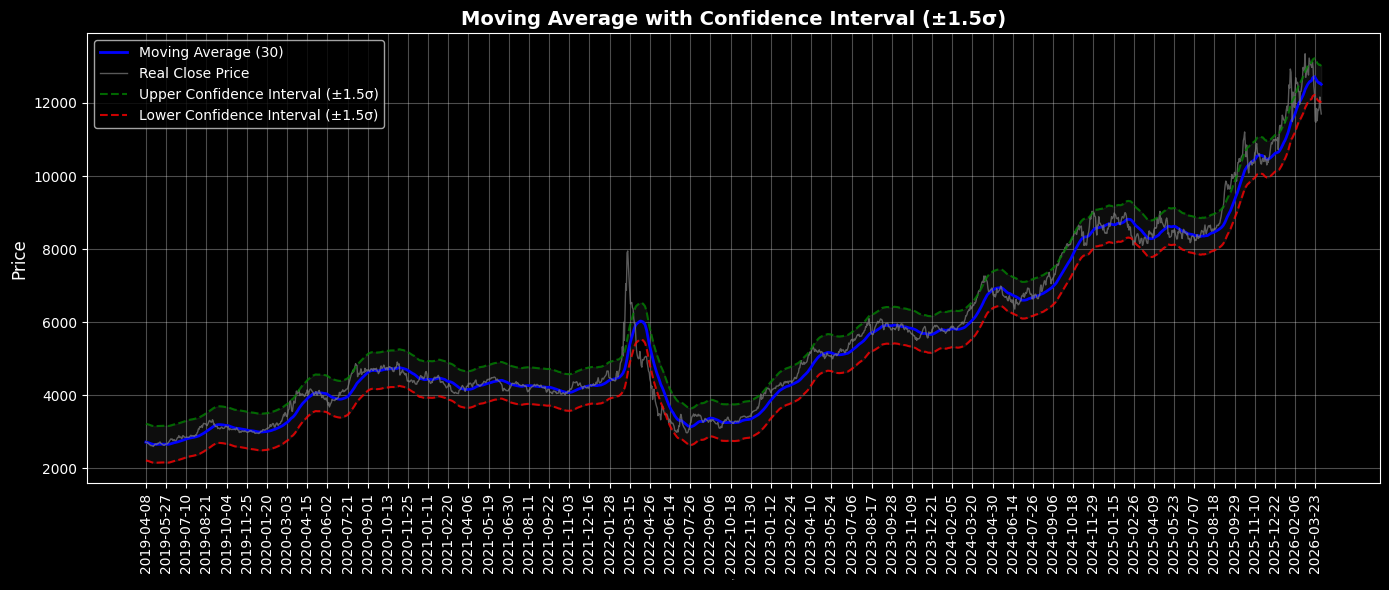

In [14]:
# Построение графика с доверительным интервалом
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_gcc_ma.index, df_gcc_ma['moving_average'], label='Moving Average (30)', linewidth=2, color='blue')
ax.plot(df_gcc_ma.index, df_gcc_ma['real_close'], label='Real Close Price', linewidth=1, alpha=0.7, color='gray')

ax.plot(df_gcc_ma.index, df_gcc_ma['close_plus_1.5_sigm'], linestyle='--', linewidth=1.5, color='green', label='Upper Confidence Interval (±1.5σ)', alpha=0.8)
ax.plot(df_gcc_ma.index, df_gcc_ma['close_minus_1.5_sigm'], linestyle='--', linewidth=1.5, color='red', label='Lower Confidence Interval (±1.5σ)', alpha=0.8)

ax.fill_between(df_gcc_ma.index, df_gcc_ma['close_minus_1.5_sigm'], df_gcc_ma['close_plus_1.5_sigm'], alpha=0.1, color='gray')

ax.set_xlabel('Date', fontsize=1)
ax.set_ylabel('Price', fontsize=12)
ax.set_title('Moving Average with Confidence Interval (±1.5σ)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(df_gcc_ma.index[::30],rotation=90)
plt.tight_layout()
plt.show()

# LSTM

In [121]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.optimizers import Adam

In [109]:
df_gold_cost.head()

,open,high,low,close
date,,,,
2019-04-08,2718.5,2727.5,2718.5,2718.5
2019-04-09,2705.0,2710.0,2705.0,2710.0
2019-04-10,2716.0,2716.0,2704.5,2707.5
2019-04-11,2702.0,2702.0,2685.0,2689.0
2019-04-12,2683.5,2683.5,2670.0,2677.5


In [110]:
df_gold_cost_train = df_gold_cost[:-60].copy()
df_gold_cost_test = df_gold_cost[-60:].copy()

scaler = MinMaxScaler()
scaler.fit(df_gold_cost_train)
df_gold_cost_train_scaled = pd.DataFrame(
    scaler.transform(df_gold_cost_train),
    columns=df_gold_cost.columns,
    index=df_gold_cost_train.index
)
df_gold_cost_test_scaled = pd.DataFrame(
    scaler.transform(df_gold_cost_test),
    columns=df_gold_cost.columns,
    index=df_gold_cost_test.index
)

In [111]:
timesteps = 30

In [112]:
def make_sequences(data, timesteps=30):
    X, y = [], []
    values = data.values
    for i in range(len(values) - timesteps):
        X.append(values[i:i+timesteps])
        y.append(values[i+timesteps])
    return np.array(X), np.array(y)

In [113]:
X_train, y_train = make_sequences(df_gold_cost_train_scaled, timesteps)

In [114]:
df_combined = pd.concat([df_gold_cost_train_scaled, df_gold_cost_test_scaled])
X_test_all, y_test_all = make_sequences(df_combined, timesteps)
X_test = X_test_all[-len(df_gold_cost_test_scaled):]
y_test = y_test_all[-len(df_gold_cost_test_scaled):]

In [115]:
model = Sequential([
    LSTM(64, input_shape=(timesteps, 4), return_sequences=True),
    Dropout(0.15),  # Снизили dropout
    LSTM(32, return_sequences=False),
    Dropout(0.15),
    Dense(16, activation='relu'),
    Dense(4)
])

D:\SUAI\Diplom\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [116]:
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

In [117]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.7, patience=5, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0360 - mae: 0.1422 - val_loss: 0.0923 - val_mae: 0.2838 - learning_rate: 5.0000e-04
Epoch 2/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0049 - mae: 0.0531 - val_loss: 0.0180 - val_mae: 0.1105 - learning_rate: 5.0000e-04
Epoch 3/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0036 - mae: 0.0429 - val_loss: 0.0138 - val_mae: 0.0980 - learning_rate: 5.0000e-04
Epoch 4/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029 - mae: 0.0384 - val_loss: 0.0133 - val_mae: 0.0992 - learning_rate: 5.0000e-04
Epoch 5/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0026 - mae: 0.0359 - val_loss: 0.0085 - val_mae: 0.0768 - learning_rate: 5.0000e-04
Epoch 6/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0024 - mae: 0.0346 - val_loss: 0.0116 - val_mae: 0.0969 - learning_rate: 5.0000e-04
Epoch 7/200
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0022 - mae: 0.0328 - val_loss: 0.0032 - val_mae: 0.0400 - lear

In [118]:
pred_scaled = model.predict(X_test)
pred_real = scaler.inverse_transform(pred_scaled)
y_test_real = scaler.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step


In [119]:
from sklearn.metrics import mean_absolute_error

columns = df_gold_cost.columns
mae_dict = {}
rmse_dict = {}

for i, col in enumerate(columns):
    mae = mean_absolute_error(y_test_real[:, i], pred_real[:, i])
    rmse = np.sqrt(np.mean((y_test_real[:, i] - pred_real[:, i]) ** 2))
    mae_dict[col] = mae
    rmse_dict[col] = rmse
    print(f"{col:6} | MAE: {mae:8.4f} | RMSE: {rmse:8.4f}")

open   | MAE: 1325.8802 | RMSE: 1406.8706
high   | MAE: 1466.2552 | RMSE: 1531.5262
low    | MAE: 601.3745 | RMSE: 674.3207
close  | MAE: 1099.7683 | RMSE: 1181.5790


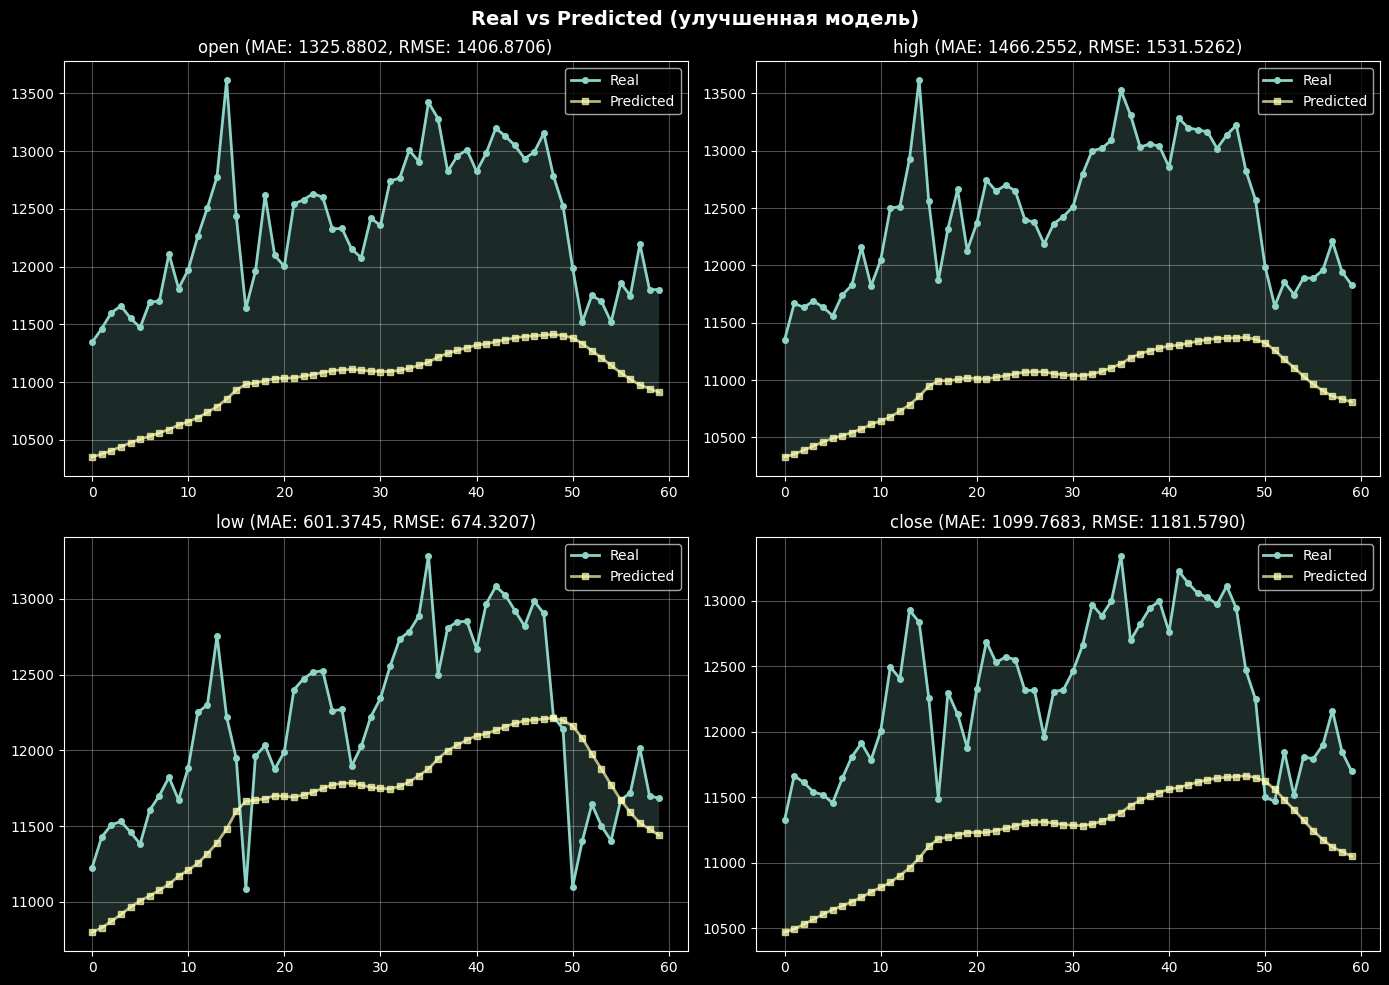

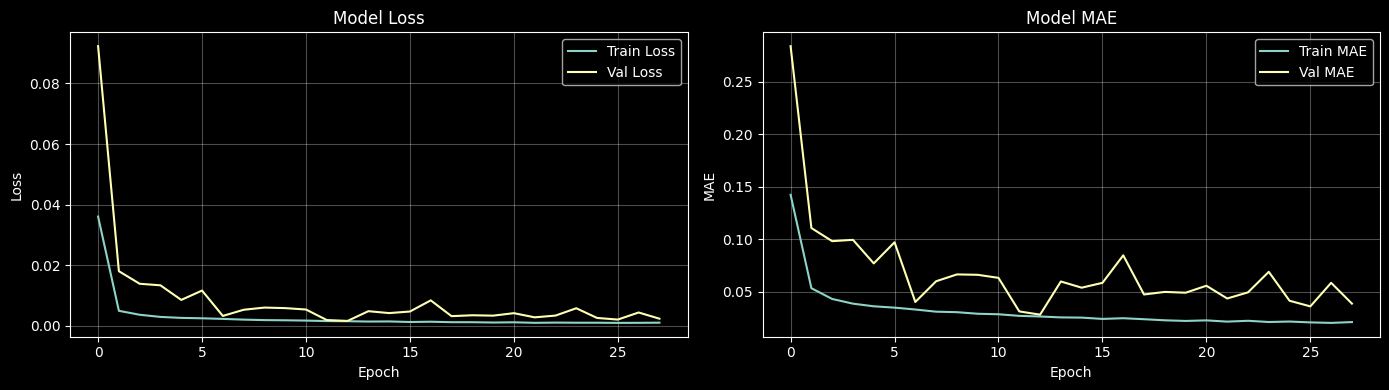

In [120]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Real vs Predicted (улучшенная модель)', fontsize=14, fontweight='bold')

for idx, col in enumerate(columns):
    ax = axes[idx // 2, idx % 2]
    ax.plot(range(len(y_test_real)), y_test_real[:, idx], label='Real', linewidth=2, marker='o', markersize=4)
    ax.plot(range(len(pred_real)), pred_real[:, idx], label='Predicted', linewidth=2, marker='s', markersize=4, alpha=0.7)
    ax.fill_between(range(len(y_test_real)), y_test_real[:, idx], pred_real[:, idx], alpha=0.2)
    ax.set_title(f'{col} (MAE: {mae_dict[col]:.4f}, RMSE: {rmse_dict[col]:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# График обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.set_title('Model Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Val MAE')
ax2.set_ylabel('MAE')
ax2.set_xlabel('Epoch')
ax2.set_title('Model MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
import pickle
from pathlib import Path

save_dir = Path("predict_model/models")
save_dir.mkdir(exist_ok=True)

bundle = {
    "model_json": model.to_json(),
    "model_weights": model.get_weights(),
    "scaler": scaler,
    "timesteps": timesteps,
    "columns": list(df_gold_cost.columns),
}

with open(save_dir / "gold_lstm_bundle.pkl", "wb") as f:
    pickle.dump(bundle, f)